# FinTrust Digital Bank - Week 2 · Data Science Track

**Programme:** AnalystLab Africa Experience Lab

**Project:** FinTrust Financial Intelligence & Digital Banking Support Solution

**Track:** Data Science — FinTrust Risk Review Predictive Model (Initial Development)

## Part A — Data Preparation

### A1–A3: Load the customer and transaction data, and join on Customer_ID

In [15]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve)

RANDOM_STATE = 42
TARGET = "Risk_Review_Target"

pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")
NAVY, ORANGE, GREY, TEAL = "#1F4E79", "#D98324", "#8C8C8C", "#2A9D8F"
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "axes.titleweight": "bold",
                     "axes.labelsize": 10, "axes.spines.top": False, "axes.spines.right": False})

# Loading the datasets

In [16]:
cust = pd.read_csv(r"D:\Analyst_lab\FinTrust_Digital_Bank_Project\data\raw\FinTrust_Customer_Data - FinTrust_Customer_Data.csv")
txn  = pd.read_csv(r"D:\Analyst_lab\FinTrust_Digital_Bank_Project\data\raw\FinTrust_Transaction_Data - FinTrust_Transaction_Data.csv")

print(f"Customer dataset   : {cust.shape[0]} rows, {cust.shape[1]} columns")
print(f"Transaction dataset: {txn.shape[0]} rows, {txn.shape[1]} columns")

Customer dataset   : 1500 rows, 12 columns
Transaction dataset: 12000 rows, 11 columns


In [17]:
cust.head()

,Customer_ID,Customer_Name,Age,Gender,City,Customer_Segment,Account_Type,Tenure_Months,Digital_Engagement_Score,Monthly_Income_Band,Preferred_Channel,Account_Status
0,FT-C00001,Ibrahim Adeyemi,56,Male,Lagos,Premium,Savings,55,84.9,500k-999k,Mobile App,Active
1,FT-C00002,Yusuf Mohammed,46,Male,Kano,Everyday,Current,79,50.7,500k-999k,Mobile App,Active
2,FT-C00003,Emeka Adeyemi,32,Female,Port Harcourt,Everyday,Savings,43,56.1,1m+,Mobile App,Active
3,FT-C00004,David Williams,60,Female,Benin City,Premium,Premium,44,54.0,500k-999k,Mobile App,Dormant
4,FT-C00005,Blessing Adeyemi,25,Male,Kaduna,Premium,Savings,68,85.1,500k-999k,Mobile App,Active


In [18]:
txn.head()

,Transaction_ID,Customer_ID,Transaction_DateTime,Transaction_Type,Amount_NGN,Channel,Device_Type,Location,International_Transaction,Transaction_Status,Risk_Review_Flag
0,FT-T000001,FT-C01135,1/1/2026 0:00,Card Purchase,5923.80,Mobile App,Android,Enugu,No,Reversed,Yes
1,FT-T000002,FT-C00428,1/1/2026 0:10,Cash Withdrawal,11681.12,ATM,Android,Kaduna,No,Successful,Yes
2,FT-T000003,FT-C00469,1/1/2026 0:21,Transfer,571.91,ATM,POS Terminal,Kano,No,Successful,No
3,FT-T000004,FT-C01015,1/1/2026 0:32,Deposit,105367.52,Mobile App,Web Browser,Abuja,No,Successful,No
4,FT-T000005,FT-C00870,1/1/2026 0:43,Cash Withdrawal,3049.06,Mobile App,POS Terminal,Abuja,No,Successful,No


In [19]:
# Join the two datasets on Customer_ID
df = txn.merge(cust, on="Customer_ID", how="left")
print(f"Joined dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Joined dataset: 12000 rows, 22 columns


,Transaction_ID,Customer_ID,Transaction_DateTime,Transaction_Type,Amount_NGN,Channel,Device_Type,Location,International_Transaction,Transaction_Status,Risk_Review_Flag,Customer_Name,Age,Gender,City,Customer_Segment,Account_Type,Tenure_Months,Digital_Engagement_Score,Monthly_Income_Band,Preferred_Channel,Account_Status
0,FT-T000001,FT-C01135,1/1/2026 0:00,Card Purchase,5923.80,Mobile App,Android,Enugu,No,Reversed,Yes,Amina Williams,44,Female,Ibadan,Everyday,Current,50,42.9,500k-999k,Mobile App,Active
1,FT-T000002,FT-C00428,1/1/2026 0:10,Cash Withdrawal,11681.12,ATM,Android,Kaduna,No,Successful,Yes,Tunde Adebayo,23,Male,Lagos,Everyday,Current,50,95.0,Below 100k,Web,Active
2,FT-T000003,FT-C00469,1/1/2026 0:21,Transfer,571.91,ATM,POS Terminal,Kano,No,Successful,No,Fatima Okafor,39,Female,Kaduna,Everyday,Current,53,64.4,100k-249k,Mobile App,Active
3,FT-T000004,FT-C01015,1/1/2026 0:32,Deposit,105367.52,Mobile App,Web Browser,Abuja,No,Successful,No,Daniel Garba,50,Female,Lagos,Everyday,Current,19,61.7,100k-249k,Mobile App,Active
4,FT-T000005,FT-C00870,1/1/2026 0:43,Cash Withdrawal,3049.06,Mobile App,POS Terminal,Abuja,No,Successful,No,Emeka Bello,58,Female,Kano,Everyday,Savings,8,76.5,100k-249k,Mobile App,Active


**Relationship between the datasets.** Each customer can have many transactions, so this is a **one-to-many relationship** joined on `Customer_ID`. Every transaction matched to a customer record (no unmatched rows), so the join is clean.

### A4: Missing values

In [20]:
print("Missing values — Customer data:")
print(cust.isnull().sum()[cust.isnull().sum() > 0])
print("\nMissing values — Transaction data:")
print(txn.isnull().sum()[txn.isnull().sum() > 0])

Missing values — Customer data:
Series([], dtype: int64)

Missing values — Transaction data:
Device_Type    96
Location       96
dtype: int64


**Finding.** The customer dataset has no missing values. In the transaction dataset, `Device_Type` and `Location` each have a small number of missing values. **Decision:** these will be filled with `"Unknown"` rather than dropped, so no transactions are lost.

### A5: Duplicate records

In [21]:
print("Duplicate rows in customer data:", cust.duplicated().sum())
print("Duplicate rows in transaction data:", txn.duplicated().sum())
print("Duplicate Customer_ID:", cust.Customer_ID.duplicated().sum())
print("Duplicate Transaction_ID:", txn.Transaction_ID.duplicated().sum())

Duplicate rows in customer data: 0
Duplicate rows in transaction data: 0
Duplicate Customer_ID: 0
Duplicate Transaction_ID: 0


**Finding.** No duplicate rows and no duplicate ID values in either dataset.

### A6: Data types

In [22]:
print(cust.dtypes)
print()
print(txn.dtypes)

Customer_ID                     str
Customer_Name                   str
Age                           int64
Gender                          str
City                            str
Customer_Segment                str
Account_Type                    str
Tenure_Months                 int64
Digital_Engagement_Score    float64
Monthly_Income_Band             str
Preferred_Channel               str
Account_Status                  str
dtype: object

Transaction_ID                   str
Customer_ID                      str
Transaction_DateTime             str
Transaction_Type                 str
Amount_NGN                   float64
Channel                          str
Device_Type                      str
Location                         str
International_Transaction        str
Transaction_Status               str
Risk_Review_Flag                 str
dtype: object


**Data-type issues found:**
- `Transaction_DateTime` is stored as text and needs to be converted to a proper datetime.
- `Risk_Review_Flag` and `International_Transaction` are text (`Yes`/`No`) and will be converted to 0/1 for modelling.

### A7: Unusual values / potential outliers

In [23]:
print(cust[["Age", "Tenure_Months", "Digital_Engagement_Score"]].describe())
print()
print(txn[["Amount_NGN"]].describe())

               Age  Tenure_Months  Digital_Engagement_Score
count  1500.000000    1500.000000               1500.000000
mean     41.587333      49.858667                 67.954000
std      13.733127      27.910990                 17.555376
min      18.000000       1.000000                 16.700000
25%      29.750000      26.000000                 56.100000
50%      42.000000      51.000000                 68.000000
75%      53.000000      74.000000                 80.925000
max      65.000000      96.000000                100.000000

          Amount_NGN
count   12000.000000
mean    46706.446238
std     86028.715234
min       100.170000
25%      2192.220000
50%     10305.935000
75%     48484.475000
max    693454.450000


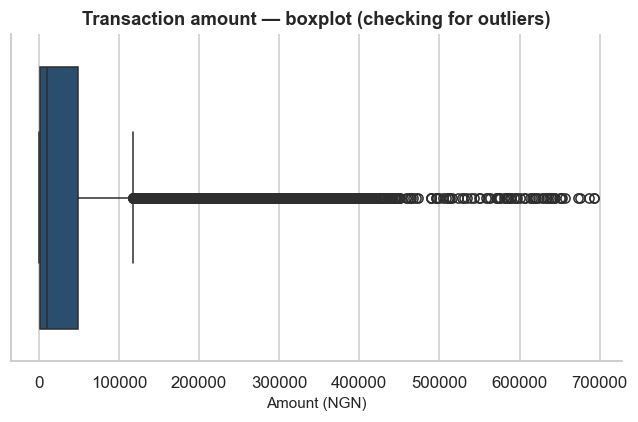

In [24]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=txn.Amount_NGN, color="#1F4E79")
plt.title("Transaction amount — boxplot (checking for outliers)")
plt.xlabel("Amount (NGN)")
plt.tight_layout()
plt.show()

**Finding.** Ages, tenure and engagement scores all looks good (no negative values or impossible ages). `Amount_NGN` has a long right tail with some high-value transactions, visible as points above the box in the boxplot. These are treated as genuine large transactions, not errors, and are kept in the dataset.

In [25]:
for col in ["Transaction_Type", "Channel", "Device_Type", "Location", "International_Transaction", "Transaction_Status"]:
    print(col, "->", txn[col].dropna().unique())

Transaction_Type -> <ArrowStringArray>
[  'Card Purchase', 'Cash Withdrawal',        'Transfer',         'Deposit',
    'Airtime/Data',    'Bill Payment']
Length: 6, dtype: str
Channel -> <ArrowStringArray>
['Mobile App', 'ATM', 'POS', 'Web', 'USSD']
Length: 5, dtype: str
Device_Type -> <ArrowStringArray>
['Android', 'POS Terminal', 'Web Browser', 'ATM Terminal', 'iOS']
Length: 5, dtype: str
Location -> <ArrowStringArray>
[        'Enugu',        'Kaduna',          'Kano',         'Abuja',
 'Port Harcourt',         'Lagos',        'Ibadan',    'Benin City']
Length: 8, dtype: str
International_Transaction -> <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
Transaction_Status -> <ArrowStringArray>
['Reversed', 'Successful', 'Failed', 'Pending']
Length: 4, dtype: str


No unexpected or misspelled category values were found.

### A8: Target distribution (`Risk_Review_Flag`)

Risk_Review_Flag
No     9648
Yes    2352
Name: count, dtype: int64

Flagged rate: 19.6%


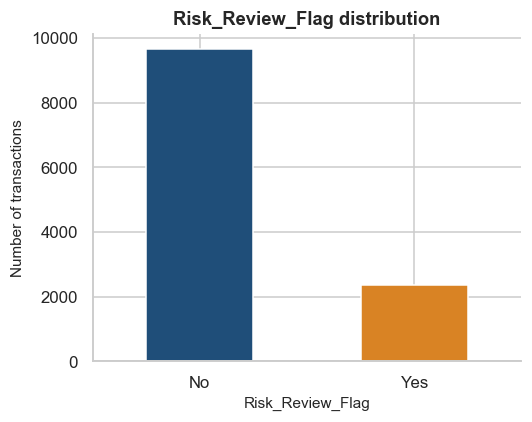

In [26]:
flag_counts = txn.Risk_Review_Flag.value_counts()
print(flag_counts)
print(f"\nFlagged rate: {(txn.Risk_Review_Flag=='Yes').mean():.1%}")

plt.figure(figsize=(5, 4))
flag_counts.plot(kind="bar", color=["#1F4E79", "#D98324"])
plt.title("Risk_Review_Flag distribution")
plt.ylabel("Number of transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Finding.** About 1 in 5 transactions (≈20%) is flagged for review. This is an **imbalanced target** - a model that simply predicted "No" for every transaction would still be right about 80% of the time, so accuracy alone will not be a good way to judge a model (this will be addressed in Part E).

### A9: Variables that may be inappropriate for modelling

In [27]:
inappropriate = pd.DataFrame({
    "Variable": ["Transaction_ID", "Customer_ID", "Customer_Name", "Transaction_DateTime (raw text)"],
    "Reason": [
        "Unique identifier — carries no predictive information, risk of the model memorising rows",
        "Identifier / join key only",
        "A display name, not a meaningful attribute; not marked for modelling use in the data dictionary",
        "Raw text is not usable directly — must be converted into features such as hour/day (done in Notebook 2)",
    ],
})
inappropriate

,Variable,Reason
0,Transaction_ID,Unique identifier — carries no predictive info...
1,Customer_ID,Identifier / join key only
2,Customer_Name,"A display name, not a meaningful attribute; no..."
3,Transaction_DateTime (raw text),Raw text is not usable directly — must be conv...


### A10: Data preparation decisions and building the prepared dataset

In [28]:
df_clean = txn.copy()
df_clean["Transaction_DateTime"] = pd.to_datetime(df_clean["Transaction_DateTime"])
df_clean["Device_Type"] = df_clean["Device_Type"].fillna("Unknown")
df_clean["Location"] = df_clean["Location"].fillna("Unknown")
df_clean["Risk_Review_Target"] = (df_clean["Risk_Review_Flag"] == "Yes").astype(int)

# join with customer data (drop the display name — not used for modelling)
cust_clean = cust.drop(columns=["Customer_Name"])
prepared = df_clean.merge(cust_clean, on="Customer_ID", how="left")

print(f"Prepared dataset: {prepared.shape[0]} rows, {prepared.shape[1]} columns")
prepared.to_csv("D:\\Analyst_lab\\FinTrust_Digital_Bank_Project\\data\\processed\\FinTrust_Modelling_Dataset_Prepared.csv", index=False)
print("Saved to D:\\Analyst_lab\\FinTrust_Digital_Bank_Project\\data\\processed\\FinTrust_Modelling_Dataset_Prepared.csv")
prepared.head()

Prepared dataset: 12000 rows, 22 columns
Saved to D:\Analyst_lab\FinTrust_Digital_Bank_Project\data\processed\FinTrust_Modelling_Dataset_Prepared.csv


,Transaction_ID,Customer_ID,Transaction_DateTime,Transaction_Type,Amount_NGN,Channel,Device_Type,Location,International_Transaction,Transaction_Status,Risk_Review_Flag,Risk_Review_Target,Age,Gender,City,Customer_Segment,Account_Type,Tenure_Months,Digital_Engagement_Score,Monthly_Income_Band,Preferred_Channel,Account_Status
0,FT-T000001,FT-C01135,2026-01-01 00:00:00,Card Purchase,5923.80,Mobile App,Android,Enugu,No,Reversed,Yes,1,44,Female,Ibadan,Everyday,Current,50,42.9,500k-999k,Mobile App,Active
1,FT-T000002,FT-C00428,2026-01-01 00:10:00,Cash Withdrawal,11681.12,ATM,Android,Kaduna,No,Successful,Yes,1,23,Male,Lagos,Everyday,Current,50,95.0,Below 100k,Web,Active
2,FT-T000003,FT-C00469,2026-01-01 00:21:00,Transfer,571.91,ATM,POS Terminal,Kano,No,Successful,No,0,39,Female,Kaduna,Everyday,Current,53,64.4,100k-249k,Mobile App,Active
3,FT-T000004,FT-C01015,2026-01-01 00:32:00,Deposit,105367.52,Mobile App,Web Browser,Abuja,No,Successful,No,0,50,Female,Lagos,Everyday,Current,19,61.7,100k-249k,Mobile App,Active
4,FT-T000005,FT-C00870,2026-01-01 00:43:00,Cash Withdrawal,3049.06,Mobile App,POS Terminal,Abuja,No,Successful,No,0,58,Female,Kano,Everyday,Savings,8,76.5,100k-249k,Mobile App,Active


**Summary of data-preparation decisions**

| Decision | Reason |
|---|---|
| Converted `Transaction_DateTime` to a proper datetime | Needed to extract hour/day features later |
| Filled missing `Device_Type` and `Location` with "Unknown" | Keeps all transactions instead of dropping rows for a small number of gaps |
| Converted `Risk_Review_Flag` to a 0/1 target column | Needed for classification modelling |
| Dropped `Customer_Name` before joining | Not a meaningful modelling variable |
| Joined transactions to customers on `Customer_ID` | Adds customer attributes to every transaction for analysis and modelling |

## Part B — Exploratory Data Analysis

The visuals below look at how the risk-review flag relates to transaction amount, transaction type, channel, device type, location, international transactions, transaction status, customer segment, account type and digital engagement, as required by the assignment.

In [29]:
prepared["Transaction_DateTime"] = pd.to_datetime(prepared["Transaction_DateTime"])
FLAG = "Risk_Review_Target"
OVERALL_RATE = prepared[FLAG].mean()
print(f"Overall flag rate: {OVERALL_RATE:.1%}")

Overall flag rate: 19.6%


### Visual 1 - Transaction amount vs. flag

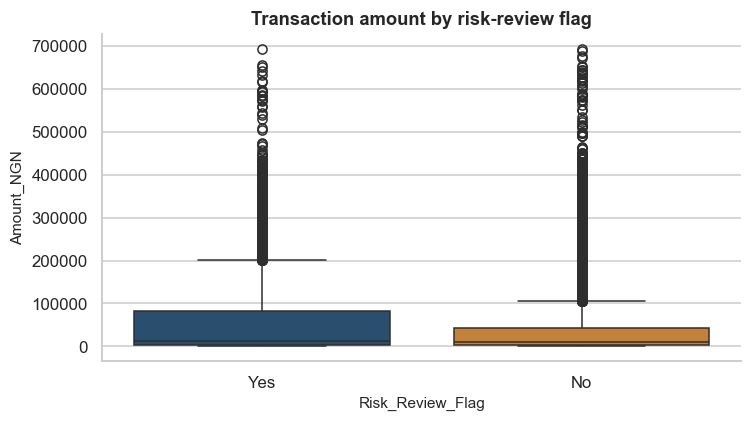

Risk_Review_Flag
No      9591.115
Yes    13541.130
Name: Amount_NGN, dtype: float64


In [30]:
plt.figure(figsize=(7, 4))
sns.boxplot(x="Risk_Review_Flag", y="Amount_NGN", data=prepared, palette=["#1F4E79", "#D98324"])
plt.title("Transaction amount by risk-review flag")
plt.tight_layout()
plt.show()
print(prepared.groupby("Risk_Review_Flag").Amount_NGN.median())

**What it shows:** Flagged transactions tend to have a higher median amount than non-flagged ones.

**Why it matters:** Amount is known the moment a transaction happens, making it a useful, easy-to-check signal.

**Business insight:** Larger transactions may deserve closer review by default.

### Visual 2 - Transaction type vs. flag rate

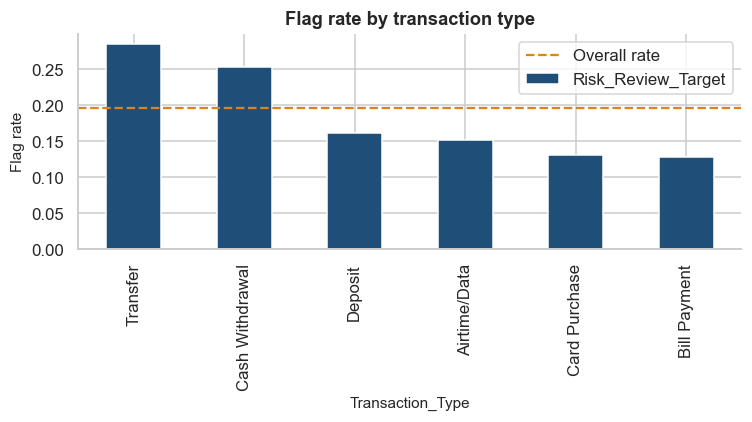

Transaction_Type
Transfer           0.284869
Cash Withdrawal    0.253147
Deposit            0.161898
Airtime/Data       0.151899
Card Purchase      0.130234
Bill Payment       0.128136
Name: Risk_Review_Target, dtype: float64

In [31]:
rate_by_type = prepared.groupby("Transaction_Type")[FLAG].mean().sort_values(ascending=False)
plt.figure(figsize=(7, 4))
rate_by_type.plot(kind="bar", color="#1F4E79")
plt.axhline(OVERALL_RATE, color="#D98324", linestyle="--", label="Overall rate")
plt.ylabel("Flag rate"); plt.title("Flag rate by transaction type"); plt.legend()
plt.tight_layout()
plt.show()
rate_by_type

**What it shows:** Transfers and cash withdrawals have a noticeably higher flag rate than other transaction types.

**Why it matters:** Transaction type is known instantly and is one of the clearer predictors in the data.

**Business insight:** "Money-out" transactions (transfers, withdrawals) may warrant closer review.

### Visual 3 - Channel vs. flag rate

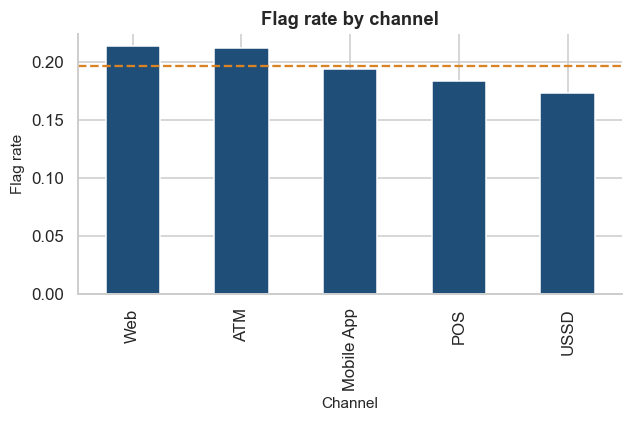

Channel
Web           0.213483
ATM           0.211792
Mobile App    0.194042
POS           0.183452
USSD          0.173228
Name: Risk_Review_Target, dtype: float64

In [32]:
rate_by_channel = prepared.groupby("Channel")[FLAG].mean().sort_values(ascending=False)
plt.figure(figsize=(6, 4))
rate_by_channel.plot(kind="bar", color="#1F4E79")
plt.axhline(OVERALL_RATE, color="#D98324", linestyle="--")
plt.ylabel("Flag rate"); plt.title("Flag rate by channel")
plt.tight_layout()
plt.show()
rate_by_channel

**What it shows:** Flag rates are fairly similar across channels, with only small differences.

**Why it matters:** Channel alone does not strongly separate flagged from non-flagged transactions.

**Business insight:** Channel is not, by itself, a strong basis for prioritising reviews.

### Visual 4 - Device type vs. flag rate

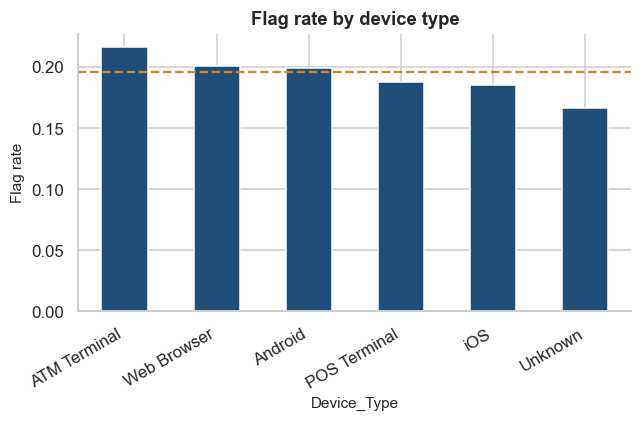

Device_Type
ATM Terminal    0.216424
Web Browser     0.201106
Android         0.199500
POS Terminal    0.187778
iOS             0.184932
Unknown         0.166667
Name: Risk_Review_Target, dtype: float64

In [33]:
rate_by_device = prepared.groupby("Device_Type")[FLAG].mean().sort_values(ascending=False)
plt.figure(figsize=(6, 4))
rate_by_device.plot(kind="bar", color="#1F4E79")
plt.axhline(OVERALL_RATE, color="#D98324", linestyle="--")
plt.ylabel("Flag rate"); plt.title("Flag rate by device type")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
rate_by_device

**What it shows:** Device type shows only small differences in flag rate.

**Why it matters:** Similar to channel, device alone is a weak predictor.

**Business insight:** Device type should not be used on its own to flag transactions.

### Visual 5 - Location (top cities) vs. flag rate

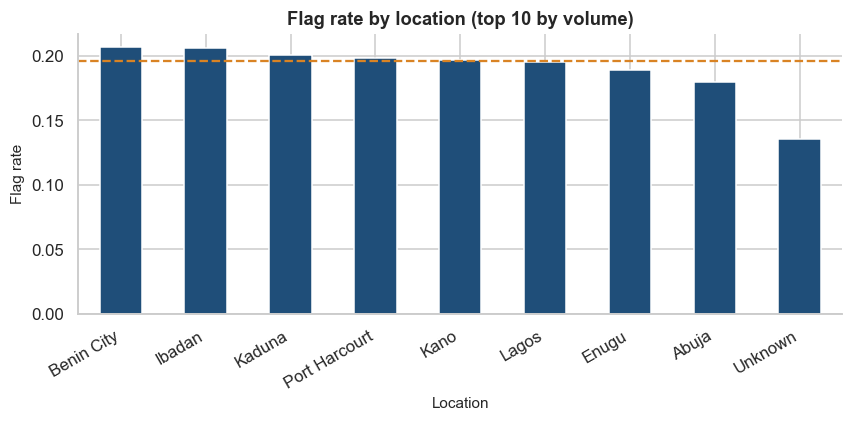

Location
Benin City       0.206754
Ibadan           0.205806
Kaduna           0.200540
Port Harcourt    0.198026
Kano             0.196592
Lagos            0.194969
Enugu            0.188679
Abuja            0.180014
Unknown          0.135417
Name: Risk_Review_Target, dtype: float64

In [34]:
top_locations = prepared.Location.value_counts().head(10).index
rate_by_location = prepared[prepared.Location.isin(top_locations)].groupby("Location")[FLAG].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
rate_by_location.plot(kind="bar", color="#1F4E79")
plt.axhline(OVERALL_RATE, color="#D98324", linestyle="--")
plt.ylabel("Flag rate"); plt.title("Flag rate by location (top 10 by volume)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
rate_by_location

**What it shows:** Flag rates are broadly similar across the top transaction locations.

**Why it matters:** Location does not appear to be a strong standalone predictor.

**Business insight:** Geography is not currently a useful lever for prioritising reviews.

### Visual 6 - International transactions vs. flag rate

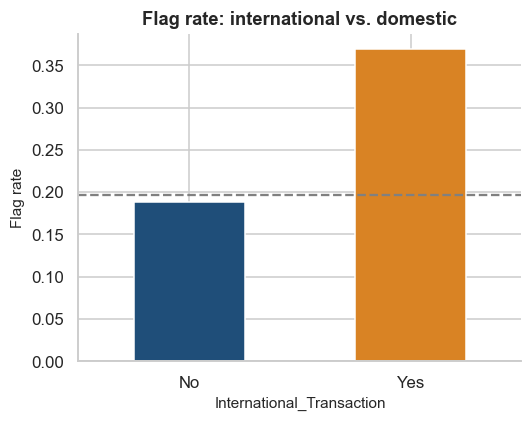

International_Transaction
No     0.188802
Yes    0.368750
Name: Risk_Review_Target, dtype: float64

In [35]:
rate_by_intl = prepared.groupby("International_Transaction")[FLAG].mean()
plt.figure(figsize=(5, 4))
rate_by_intl.plot(kind="bar", color=["#1F4E79", "#D98324"])
plt.axhline(OVERALL_RATE, color="grey", linestyle="--")
plt.ylabel("Flag rate"); plt.title("Flag rate: international vs. domestic")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
rate_by_intl

**What it shows:** International transactions have a clearly higher flag rate than domestic ones.

**Why it matters:** This is one of the strongest single indicators found in the data.

**Business insight:** International transactions are good candidates for closer review.

### Visual 7 - Transaction status vs. flag rate

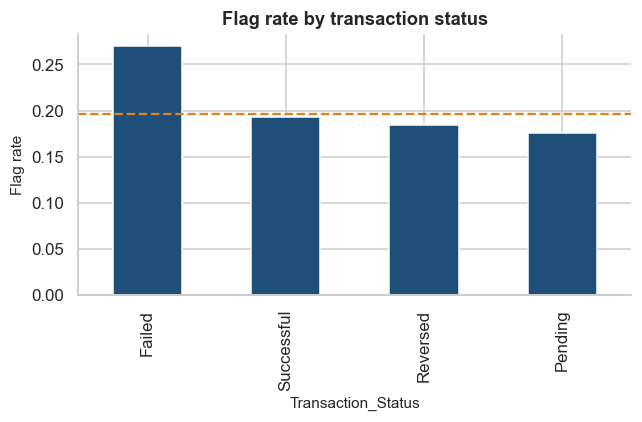

Transaction_Status
Failed        0.269841
Successful    0.192428
Reversed      0.184049
Pending       0.175532
Name: Risk_Review_Target, dtype: float64

In [36]:
rate_by_status = prepared.groupby("Transaction_Status")[FLAG].mean().sort_values(ascending=False)
plt.figure(figsize=(6, 4))
rate_by_status.plot(kind="bar", color="#1F4E79")
plt.axhline(OVERALL_RATE, color="#D98324", linestyle="--")
plt.ylabel("Flag rate"); plt.title("Flag rate by transaction status")
plt.tight_layout()
plt.show()
rate_by_status

**What it shows:** Failed transactions have a somewhat higher flag rate than successful, reversed or pending ones.

**Why it matters:** Status may only be known after a transaction is processed, so it is useful for analysis but needs care if used for real-time prediction.

**Business insight:** Failed transactions could be worth a closer look as part of routine monitoring.

### Visual 8 - Customer segment and account type vs. flag rate

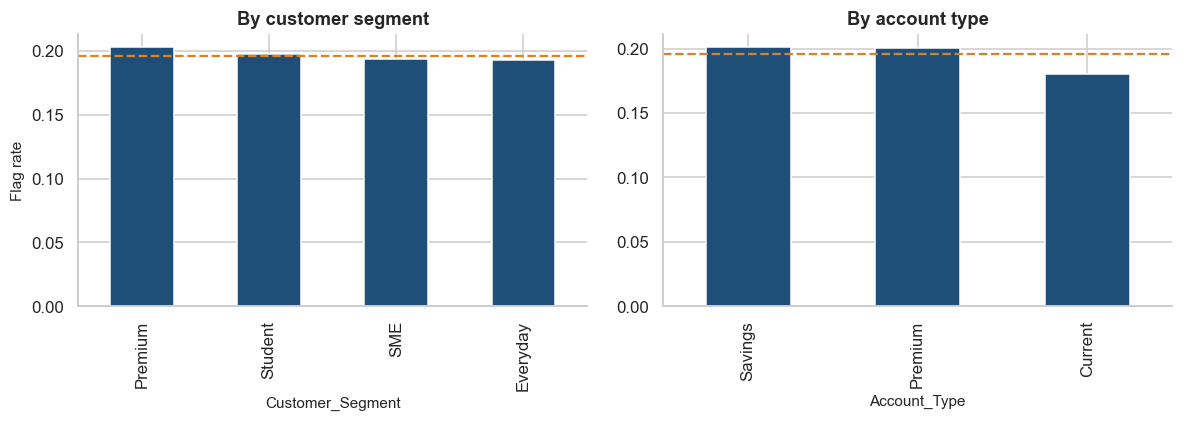

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
prepared.groupby("Customer_Segment")[FLAG].mean().sort_values(ascending=False).plot(kind="bar", ax=ax[0], color="#1F4E79")
ax[0].axhline(OVERALL_RATE, color="#D98324", linestyle="--"); ax[0].set_title("By customer segment"); ax[0].set_ylabel("Flag rate")
prepared.groupby("Account_Type")[FLAG].mean().sort_values(ascending=False).plot(kind="bar", ax=ax[1], color="#1F4E79")
ax[1].axhline(OVERALL_RATE, color="#D98324", linestyle="--"); ax[1].set_title("By account type")
plt.tight_layout()
plt.show()

**What it shows:** Flag rates are similar across customer segments and account types.

**Why it matters:** Who the customer is (their segment or account type) does not appear to strongly influence whether a transaction is flagged.

**Business insight:** Risk indicators should focus on the transaction itself rather than customer categories, which also helps avoid treating whole customer groups as inherently riskier.

### Visual 9 - Digital engagement score vs. flag rate

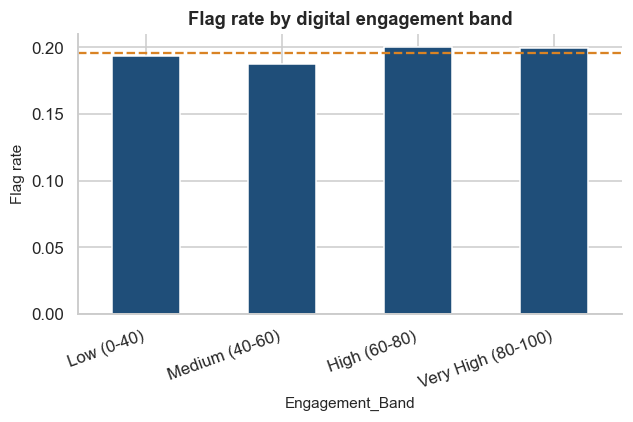

Engagement_Band
Low (0-40)            0.193464
Medium (40-60)        0.187596
High (60-80)          0.200042
Very High (80-100)    0.199136
Name: Risk_Review_Target, dtype: float64

In [38]:
prepared["Engagement_Band"] = pd.cut(prepared.Digital_Engagement_Score, [0, 40, 60, 80, 100],
                                     labels=["Low (0-40)", "Medium (40-60)", "High (60-80)", "Very High (80-100)"])
rate_by_eng = prepared.groupby("Engagement_Band", observed=True)[FLAG].mean()
plt.figure(figsize=(6, 4))
rate_by_eng.plot(kind="bar", color="#1F4E79")
plt.axhline(OVERALL_RATE, color="#D98324", linestyle="--")
plt.ylabel("Flag rate"); plt.title("Flag rate by digital engagement band")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()
rate_by_eng

**What it shows:** Flag rate does not change much across digital engagement bands.

**Why it matters:** Digital engagement does not appear to be a useful predictor on its own.

**Business insight:** Engagement level is not a reliable signal for prioritising risk review.

## Part B Summary

| Variable | Relationship with flag rate |
|---|---|
| Transaction amount | Higher amounts → somewhat higher flag rate |
| Transaction type | Transfers & cash withdrawals → higher flag rate |
| International transaction | Clearly higher flag rate for international |
| Transaction status | Failed transactions → slightly higher flag rate |
| Channel, device type, location | Little difference |
| Customer segment, account type, digital engagement | Little difference |

These findings guide the feature engineering and modelling work in **Notebook 2**.

## Part C - Feature Engineering

8 useful predictive features are created below, each documented with how it was made and why it may matter.

In [39]:
df = pd.read_csv("D:\\Analyst_lab\\FinTrust Digital Bank\\FinTrust_Week2_DS\\data\\processed\\FinTrust_Modelling_Dataset_Prepared.csv", parse_dates=["Transaction_DateTime"])
print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded 12000 rows, 22 columns


,Transaction_ID,Customer_ID,Transaction_DateTime,Transaction_Type,Amount_NGN,Channel,Device_Type,Location,International_Transaction,Transaction_Status,Risk_Review_Flag,Risk_Review_Target,Age,Gender,City,Customer_Segment,Account_Type,Tenure_Months,Digital_Engagement_Score,Monthly_Income_Band,Preferred_Channel,Account_Status
0,FT-T000001,FT-C01135,2026-01-01 00:00:00,Card Purchase,5923.80,Mobile App,Android,Enugu,No,Reversed,Yes,1,44,Female,Ibadan,Everyday,Current,50,42.9,500k-999k,Mobile App,Active
1,FT-T000002,FT-C00428,2026-01-01 00:10:00,Cash Withdrawal,11681.12,ATM,Android,Kaduna,No,Successful,Yes,1,23,Male,Lagos,Everyday,Current,50,95.0,Below 100k,Web,Active
2,FT-T000003,FT-C00469,2026-01-01 00:21:00,Transfer,571.91,ATM,POS Terminal,Kano,No,Successful,No,0,39,Female,Kaduna,Everyday,Current,53,64.4,100k-249k,Mobile App,Active
3,FT-T000004,FT-C01015,2026-01-01 00:32:00,Deposit,105367.52,Mobile App,Web Browser,Abuja,No,Successful,No,0,50,Female,Lagos,Everyday,Current,19,61.7,100k-249k,Mobile App,Active
4,FT-T000005,FT-C00870,2026-01-01 00:43:00,Cash Withdrawal,3049.06,Mobile App,POS Terminal,Abuja,No,Successful,No,0,58,Female,Kano,Everyday,Savings,8,76.5,100k-249k,Mobile App,Active


In [40]:
# 1. Transaction hour
df["Transaction_Hour"] = df.Transaction_DateTime.dt.hour

# 2. Transaction day (day of week)
df["Transaction_Day"] = df.Transaction_DateTime.dt.day_name()

# 3. Transaction amount band
df["Amount_Band"] = pd.cut(df.Amount_NGN, [0, 10_000, 50_000, 150_000, np.inf],
                            labels=["Low (<10k)", "Medium (10-50k)", "High (50-150k)", "Very High (150k+)"])

# 4. Customer tenure band
df["Tenure_Band"] = pd.cut(df.Tenure_Months, [0, 12, 24, 48, 96],
                            labels=["<1 year", "1-2 years", "2-4 years", "4+ years"])

# 5. Digital engagement category
df["Engagement_Category"] = pd.cut(df.Digital_Engagement_Score, [0, 40, 70, 100], labels=["Low", "Medium", "High"])

# 6. International transaction indicator
df["Is_International"] = (df.International_Transaction == "Yes").astype(int)

# 7. Customer transaction count (how many transactions this customer has in the data)
txn_count = df.groupby("Customer_ID").Customer_ID.transform("count")
df["Customer_Transaction_Count"] = txn_count

# 8. Transaction frequency (transactions per month of tenure)
df["Transaction_Frequency"] = df.Customer_Transaction_Count / df.Tenure_Months.replace(0, 1)

feature_doc = pd.DataFrame([
    ["Transaction_Hour",           "Hour extracted from Transaction_DateTime",                       "Certain hours of the day may be associated with higher risk"],
    ["Transaction_Day",            "Day name extracted from Transaction_DateTime",                    "Weekday vs weekend patterns may relate to risk"],
    ["Amount_Band",                "Amount_NGN grouped into 4 bands",                                 "EDA showed higher amounts relate to a higher flag rate"],
    ["Tenure_Band",                "Tenure_Months grouped into 4 bands",                              "Newer vs longer-standing customers may behave differently"],
    ["Engagement_Category",        "Digital_Engagement_Score grouped into Low/Medium/High",           "Digital engagement level was suggested as a candidate feature in the assignment"],
    ["Is_International",           "1 if International_Transaction is 'Yes', else 0",                "EDA showed international transactions have a clearly higher flag rate"],
    ["Customer_Transaction_Count", "Count of transactions for each customer",                         "Customers with unusually few or many transactions may differ in risk"],
    ["Transaction_Frequency",      "Customer_Transaction_Count divided by Tenure_Months",             "Captures how actively a customer transacts relative to how long they have been a customer"],
], columns=["Feature", "How It Was Created", "Why It May Matter"])
display(feature_doc.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "normal"}))

Feature,How It Was Created,Why It May Matter
Transaction_Hour,Hour extracted from Transaction_DateTime,Certain hours of the day may be associated with higher risk
Transaction_Day,Day name extracted from Transaction_DateTime,Weekday vs weekend patterns may relate to risk
Amount_Band,Amount_NGN grouped into 4 bands,EDA showed higher amounts relate to a higher flag rate
Tenure_Band,Tenure_Months grouped into 4 bands,Newer vs longer-standing customers may behave differently
Engagement_Category,Digital_Engagement_Score grouped into Low/Medium/High,Digital engagement level was suggested as a candidate feature in the assignment
Is_International,"1 if International_Transaction is 'Yes', else 0",EDA showed international transactions have a clearly higher flag rate
Customer_Transaction_Count,Count of transactions for each customer,Customers with unusually few or many transactions may differ in risk
Transaction_Frequency,Customer_Transaction_Count divided by Tenure_Months,Captures how actively a customer transacts relative to how long they have been a customer


## Part D - Baseline Model Development

**Model choice.** Logistic Regression is used as the baseline classification model because it is simple, fast to train, and its output is easy to explain — a good starting point before trying more complex algorithms.

## Prepare and split the modelling data

In [41]:
model_features = ["Amount_NGN", "Transaction_Hour", "Is_International", "Customer_Transaction_Count",
                  "Transaction_Frequency", "Tenure_Months", "Digital_Engagement_Score", "Age",
                  "Transaction_Type", "Channel", "Customer_Segment", "Account_Type"]

X = pd.get_dummies(df[model_features], columns=["Transaction_Type", "Channel", "Customer_Segment", "Account_Type"], drop_first=True)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(f"Training set: {X_train.shape[0]} rows | Test set: {X_test.shape[0]} rows")
print(f"Flag rate — train: {y_train.mean():.1%} | test: {y_test.mean():.1%}")

# scale the numeric columns so all features are on a comparable range (helps the model train properly)
numeric_cols = ["Amount_NGN", "Transaction_Hour", "Customer_Transaction_Count", "Transaction_Frequency",
                "Tenure_Months", "Digital_Engagement_Score", "Age"]
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

Training set: 9600 rows | Test set: 2400 rows
Flag rate — train: 19.6% | test: 19.6%


**Note on the split.** `test_size=0.2` with `stratify=y` keeps the same ~20% flag rate in both the training and test sets, which matters because the target is imbalanced. Numeric columns are scaled with `StandardScaler` (fit on the training set only) so that a large-magnitude column like `Amount_NGN` does not dominate the model purely because of its scale.

## Train the model and generate predition

In [42]:
model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
print("Model trained.")

Model trained.


**Note on `class_weight='balanced'`.** Because only about 20% of transactions are flagged, this setting tells the model to pay more attention to the minority (flagged) class during training rather than being biased toward always predicting "No".

## Part E - Model Evaluation

**Why these metrics.** Because only ~20% of transactions are flagged, **accuracy alone can be misleading** - a model that always predicts "No" would still be about 80% accurate while missing every flagged transaction. Precision, Recall, F1-score and ROC-AUC give a fuller picture of how well the model finds flagged transactions.

In [43]:
print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall   :", round(recall_score(y_test, y_pred), 3))
print("F1-score :", round(f1_score(y_test, y_pred), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_proba), 3))

Accuracy : 0.635
Precision: 0.289
Recall   : 0.594
F1-score : 0.389
ROC-AUC  : 0.668


# Confusion Matrix

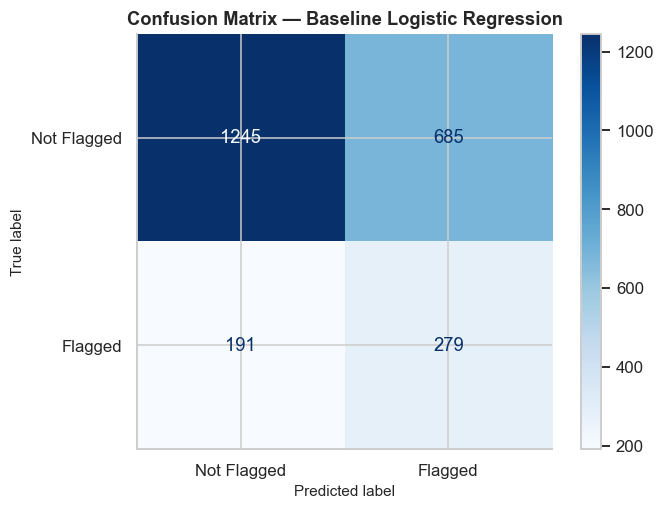

In [44]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Not Flagged", "Flagged"]).plot(cmap="Blues")
plt.title("Confusion Matrix — Baseline Logistic Regression")
plt.tight_layout()
plt.show()

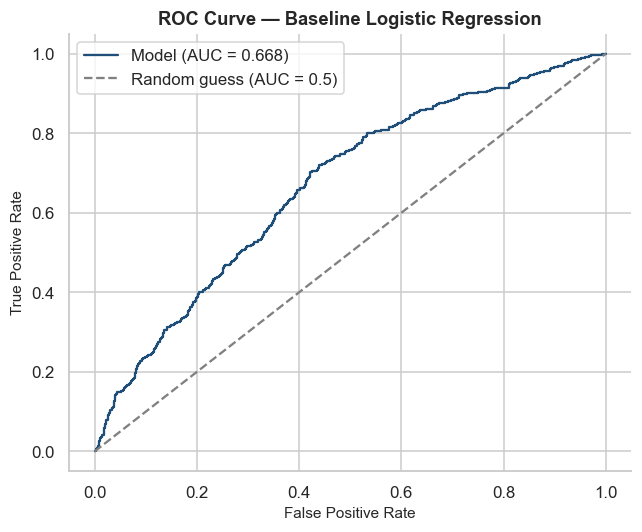

In [45]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="#1F4E79", label=f"Model (AUC = {roc_auc_score(y_test, y_proba):.3f})")
plt.plot([0, 1], [0, 1], "--", color="grey", label="Random guess (AUC = 0.5)")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

**Reading the results.** The confusion matrix shows how many flagged and non-flagged transactions the model got right and wrong. The ROC curve sits above the "random guess" diagonal, meaning the model has learned something useful - its ROC-AUC score summarises how well it ranks flagged transactions above non-flagged ones. Recall matters here because failing to catch a transaction that should be reviewed (a false negative) is usually more costly than reviewing one unnecessarily (a false positive).

## Part F - Initial Model Interpretation

### Important features influencing the model

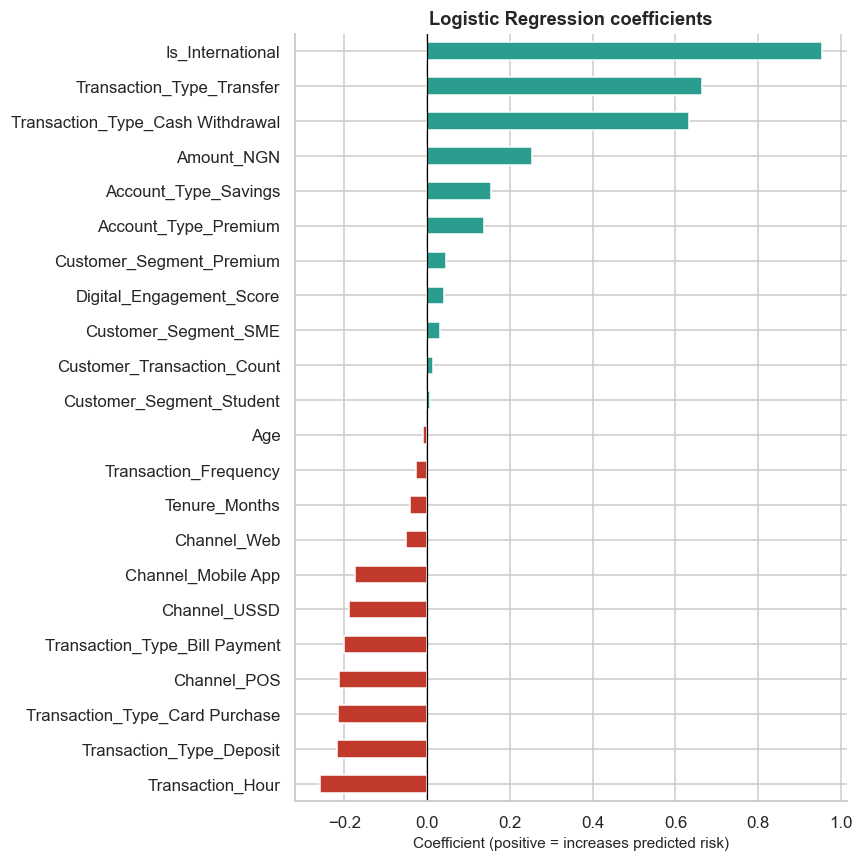

In [46]:
coefficients = pd.Series(model.coef_[0], index=X_train.columns).sort_values()
plt.figure(figsize=(8, 8))
colors = ["#C0392B" if v < 0 else "#2A9D8F" for v in coefficients]
coefficients.plot(kind="barh", color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression coefficients")
plt.xlabel("Coefficient (positive = increases predicted risk)")
plt.tight_layout()
plt.show()

In [47]:
top_positive = coefficients.sort_values(ascending=False).head(5)
top_negative = coefficients.sort_values().head(5)
print("Top features increasing predicted risk:")
print(top_positive)
print("\nTop features decreasing predicted risk:")
print(top_negative)

Top features increasing predicted risk:
Is_International                    0.952894
Transaction_Type_Transfer           0.664839
Transaction_Type_Cash Withdrawal    0.631720
Amount_NGN                          0.253671
Account_Type_Savings                0.155752
dtype: float64

Top features decreasing predicted risk:
Transaction_Hour                 -0.258312
Transaction_Type_Deposit         -0.218302
Transaction_Type_Card Purchase   -0.215898
Channel_POS                      -0.211308
Transaction_Type_Bill Payment    -0.199312
dtype: float64


### Feature → Evidence → Interpretation

In [48]:
interpretation = pd.DataFrame([
    ["Amount_NGN",           "Positive coefficient",  "Larger transaction amounts are associated with a higher predicted risk, matching what the EDA showed in Notebook 1."],
    ["Is_International",     "Positive coefficient",  "International transactions increase predicted risk, consistent with the clear gap seen in the EDA."],
    ["Transaction_Type (Transfer/Cash Withdrawal)", "Positive coefficients for these categories", "Money-out transaction types were already shown to have a higher flag rate in the EDA."],
    ["Customer_Transaction_Count / Transaction_Frequency", "Small coefficients", "Customer activity level has only a minor relationship with the flag in this model."],
    ["Customer_Segment / Account_Type", "Coefficients close to zero", "Confirms the EDA finding that customer category has little effect on the flag."],
], columns=["Feature", "Evidence", "Interpretation"])
display(interpretation.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "normal"}))

Feature,Evidence,Interpretation
Amount_NGN,Positive coefficient,"Larger transaction amounts are associated with a higher predicted risk, matching what the EDA showed in Notebook 1."
Is_International,Positive coefficient,"International transactions increase predicted risk, consistent with the clear gap seen in the EDA."
Transaction_Type (Transfer/Cash Withdrawal),Positive coefficients for these categories,Money-out transaction types were already shown to have a higher flag rate in the EDA.
Customer_Transaction_Count / Transaction_Frequency,Small coefficients,Customer activity level has only a minor relationship with the flag in this model.
Customer_Segment / Account_Type,Coefficients close to zero,Confirms the EDA finding that customer category has little effect on the flag.


### Model limitations
- The ROC-AUC score shows the model has learned a real but moderate signal - it is a starting point, not a highly accurate classifier.
- Logistic Regression assumes a fairly simple relationship between features and the outcome; it may not capture more complex patterns in the data.

### Data limitations
- `Risk_Review_Flag` is a synthetic label with an unknown generation rule, so the patterns found describe this training dataset rather than real banking risk.
- Only three months of data were available, which limits how confident we can be that these patterns would hold over a longer period.

### Possible sources of bias
- `Customer_Segment` and `Account_Type` were kept as model inputs even though the EDA and coefficients suggest they add little value; before any real use, predictions should be checked across customer segments to confirm no group is being treated unfairly.

### Areas requiring further investigation
- Try other baseline algorithms (e.g. Decision Tree, Random Forest) for comparison.
- Test different decision thresholds instead of the default 0.5 cut-off.
- Investigate `Transaction_Status` and `Account_Status` more closely, since they were left out of this baseline as they may not always be known at the time a transaction happens.